In [1]:
import pandas as pd
df = pd.read_csv("../data/NY-House-Dataset.csv")
print(df.head())

                                         BROKERTITLE                TYPE  \
0        Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                Brokered by Serhant      Condo for sale   
2                             Brokered by Sowae Corp      House for sale   
3                                Brokered by COMPASS      Condo for sale   
4  Brokered by Sotheby's International Realty - E...  Townhouse for sale   

       PRICE  BEDS       BATH  PROPERTYSQFT  \
0     315000     2   2.000000        1400.0   
1  195000000     7  10.000000       17545.0   
2     260000     4   2.000000        2015.0   
3      69000     3   1.000000         445.0   
4   55000000     7   2.373861       14175.0   

                                             ADDRESS                    STATE  \
0                               2 E 55th St Unit 803       New York, NY 10022   
1  Central Park Tower Penthouse-217 W 57th New Yo...       New York, NY 10019   
2                

Dataset after cleaning: 3709 rows
Computing hub distances (Fast Mode)...
Total features: 19
Training stacking ensemble (~1-2 min)...

R-squared : 80.35%
MAE       : $245,289

MAE by Borough:
  Bronx          : $117,361
  Brooklyn       : $237,307
  Manhattan      : $480,269
  Queens         : $108,567
  Staten Island  : $109,436


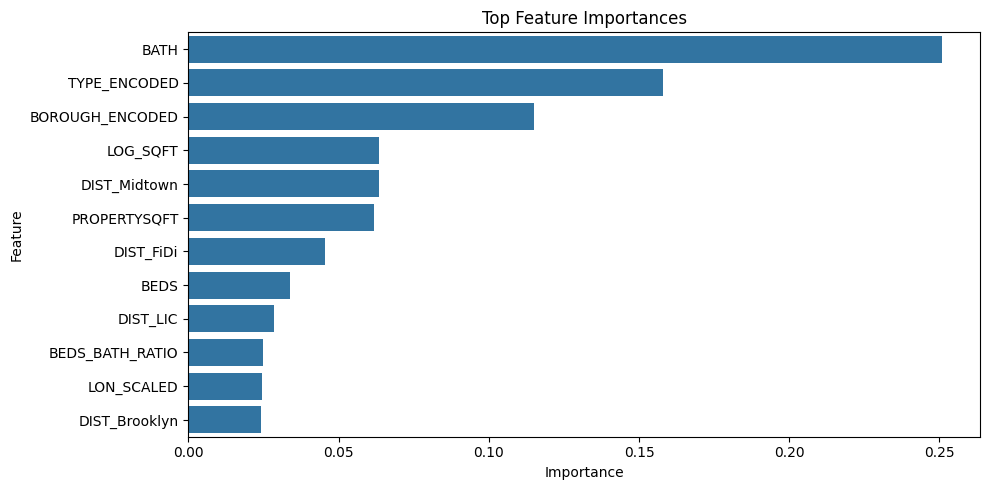

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from geopy.distance import geodesic
import joblib
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# STEP 1: Load & Clean
# ==========================================
df = pd.read_csv("../data/NY-House-Dataset.csv")
df = df.drop_duplicates()
df = df.dropna(subset=['PRICE','BEDS','BATH','PROPERTYSQFT','LATITUDE','LONGITUDE','TYPE','SUBLOCALITY'])

allowed_types = [
    'Condo for sale','House for sale','Townhouse for sale',
    'Co-op for sale','Multi-family home for sale'
]
df = df[df['TYPE'].isin(allowed_types)]

def clean_borough(name):
    name = str(name).lower()
    if any(x in name for x in ['bronx','riverdale']): return 'Bronx'
    if any(x in name for x in ['brooklyn','kings','coney island','dumbo']): return 'Brooklyn'
    if any(x in name for x in ['manhattan','new york']): return 'Manhattan'
    if any(x in name for x in ['queens','flushing','jackson heights','rego park']): return 'Queens'
    if any(x in name for x in ['staten island','richmond']): return 'Staten Island'
    return 'Other'

df['SUBLOCALITY_CLEAN'] = df['SUBLOCALITY'].apply(clean_borough)
df = df[df['SUBLOCALITY_CLEAN'] != 'Other']

# ==========================================
# STEP 2: Outlier Removal (IQR per borough)
# ==========================================
def remove_outliers_iqr(data, col):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - 1.5*IQR) & (data[col] <= Q3 + 1.5*IQR)]

# Loop per borough — avoids pandas groupby column-dropping bug in newer versions
chunks = []
for boro in df['SUBLOCALITY_CLEAN'].unique():
    group = df[df['SUBLOCALITY_CLEAN'] == boro].copy()
    group = remove_outliers_iqr(group, 'PRICE')
    group = remove_outliers_iqr(group, 'PROPERTYSQFT')
    chunks.append(group)

df_cleaned = pd.concat(chunks).reset_index(drop=True)
print(f"Dataset after cleaning: {len(df_cleaned)} rows")
df_cleaned.to_csv("../data/NY_House_Cleaned.csv", index=False)

# ==========================================
# STEP 3: Feature Engineering
# ==========================================
ECONOMIC_HUBS = {
    'Midtown':    (40.7580,-73.9855),
    'FiDi':       (40.7081,-74.0093),
    'Brooklyn':   (40.6925,-73.9868),
    'LIC':        (40.7447,-73.9485),
    'Flushing':   (40.7654,-73.8282),
    'Jamaica':    (40.7024,-73.7966),
    'SouthBronx': (40.8162,-73.9165),
    'StGeorge':   (40.6437,-74.0759),
}

def hub_distances(lat, lon):
    return {k: geodesic((lat,lon), v).miles for k,v in ECONOMIC_HUBS.items()}

# --- แก้ไขเฉพาะส่วนนี้ใน STEP 3 ---
print("Computing hub distances (Fast Mode)...")
for k, v in ECONOMIC_HUBS.items():
    # คำนวณทีละ Hub และสร้างคอลัมน์ใหม่ลงใน df_cleaned โดยตรง
    df_cleaned[f'DIST_{k}'] = df_cleaned.apply(lambda r: geodesic((r['LATITUDE'], r['LONGITUDE']), v).miles, axis=1)

# หาค่าที่น้อยที่สุดจากคอลัมน์ระยะทางทั้งหมดที่เพิ่งสร้าง
df_cleaned['DISTANCE_TO_CENTER'] = df_cleaned[[f'DIST_{k}' for k in ECONOMIC_HUBS.keys()]].min(axis=1)
# --------------------------------

# Derived numeric features
df_cleaned['LOG_SQFT']        = np.log1p(df_cleaned['PROPERTYSQFT'])
df_cleaned['SQFT_PER_BED']    = df_cleaned['PROPERTYSQFT'] / df_cleaned['BEDS'].replace(0, 1)
df_cleaned['BEDS_BATH_RATIO'] = df_cleaned['BEDS'] / df_cleaned['BATH'].replace(0, 1)

# Scale lat/lon
scaler = MinMaxScaler()
df_cleaned[['LAT_SCALED','LON_SCALED']] = scaler.fit_transform(df_cleaned[['LATITUDE','LONGITUDE']])

# Target
y = pd.Series(np.log1p(df_cleaned['PRICE'].values), index=df_cleaned.index)

# ==========================================
# TARGET ENCODING (k-fold to prevent leakage)
# ==========================================
def kfold_target_encode(series, target, n_splits=5):
    encoded = np.zeros(len(series))
    global_mean = target.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr_idx, val_idx in kf.split(series):
        fold_means = target.iloc[tr_idx].groupby(series.iloc[tr_idx]).mean()
        encoded[val_idx] = series.iloc[val_idx].map(fold_means).fillna(global_mean).values
    return encoded

df_cleaned['TYPE_ENCODED']    = kfold_target_encode(df_cleaned['TYPE'],              y)
df_cleaned['BOROUGH_ENCODED'] = kfold_target_encode(df_cleaned['SUBLOCALITY_CLEAN'], y)

TYPE_ENC_MAP    = y.groupby(df_cleaned['TYPE']).mean().to_dict()
BOROUGH_ENC_MAP = y.groupby(df_cleaned['SUBLOCALITY_CLEAN']).mean().to_dict()

# ==========================================
# STEP 4: Build Feature Matrix
# ==========================================
FINAL_FEATURES = [
    'BEDS','BATH','PROPERTYSQFT','LOG_SQFT','SQFT_PER_BED','BEDS_BATH_RATIO',
    'LAT_SCALED','LON_SCALED','DISTANCE_TO_CENTER',
    'DIST_Midtown','DIST_FiDi','DIST_Brooklyn',
    'DIST_LIC','DIST_Flushing','DIST_Jamaica','DIST_SouthBronx','DIST_StGeorge',
    'TYPE_ENCODED','BOROUGH_ENCODED',
]

X = df_cleaned[FINAL_FEATURES].astype(float)
print(f"Total features: {len(FINAL_FEATURES)}")

# ==========================================
# STEP 5: Train / Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 6: Stacking Ensemble
# ==========================================
base_models = [
    ('hgb', HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.04,
        max_depth=6, min_samples_leaf=15,
        l2_regularization=0.1, random_state=42
    )),
    ('et', ExtraTreesRegressor(
        n_estimators=300, max_depth=None,
        min_samples_leaf=3, max_features=0.7,
        random_state=42, n_jobs=-1
    )),
]

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)

print("Training stacking ensemble (~1-2 min)...")
stacking_model.fit(X_train, y_train)

# ==========================================
# STEP 7: Evaluate
# ==========================================
y_pred_log    = stacking_model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

r2  = r2_score(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("\n" + "="*50)
print(f"R-squared : {r2*100:.2f}%")
print(f"MAE       : ${mae:,.0f}")
print("="*50)

boroughs = df_cleaned.loc[y_test.index, 'SUBLOCALITY_CLEAN'].values
print("\nMAE by Borough:")
for boro in sorted(set(boroughs)):
    mask = boroughs == boro
    b_mae = mean_absolute_error(y_test_actual[mask], y_pred_actual[mask])
    print(f"  {boro:<15}: ${b_mae:,.0f}")

et = stacking_model.estimators_[1]
feat_df = pd.DataFrame({'Feature': FINAL_FEATURES, 'Importance': et.feature_importances_})
feat_df = feat_df.sort_values('Importance', ascending=False).head(12)
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Top Feature Importances')
plt.tight_layout()
plt.show()

In [5]:
print(f"จำนวนข้อมูลทั้งหมดใน Training Set: {len(X_train)} รายการ")
print("-" * 30)
print("5 แถวแรกของ X_train (Features):")
display(X_train.head())

print("\n5 แถวแรกของ y_train (Target - Log Price):")
display(y_train.head())

จำนวนข้อมูลทั้งหมดใน Training Set: 2967 รายการ
------------------------------
5 แถวแรกของ X_train (Features):


,BEDS,BATH,PROPERTYSQFT,LOG_SQFT,SQFT_PER_BED,BEDS_BATH_RATIO,LAT_SCALED,LON_SCALED,DISTANCE_TO_CENTER,DIST_Midtown,DIST_FiDi,DIST_Brooklyn,DIST_LIC,DIST_Flushing,DIST_Jamaica,DIST_SouthBronx,DIST_StGeorge,TYPE_ENCODED,BOROUGH_ENCODED
964,3.0,2.0,1440.000000,7.273093,480.000000,1.5,0.038995,0.038775,12.031559,21.124614,17.674289,17.722095,21.692198,27.307687,26.241081,26.519103,12.031559,13.628025,13.423430
507,1.0,1.0,692.000000,6.541030,692.000000,1.0,0.658235,0.551270,1.857077,2.112945,5.392460,5.800330,1.857077,6.373743,9.334785,3.528425,11.045408,13.772505,14.020039
7,1.0,1.0,2184.207862,7.689466,2184.207862,1.0,0.679138,0.487288,1.535003,1.535003,5.143141,6.055054,3.099439,8.269800,11.235393,4.350089,10.569974,13.123043,14.020039
2123,1.0,1.0,2184.207862,7.689466,2184.207862,1.0,0.411910,0.509044,1.728044,6.117156,3.264336,1.728044,5.315737,10.047717,9.515935,10.517279,5.718304,13.123043,13.607393
2833,4.0,2.0,2184.207862,7.689466,546.051966,2.0,0.548214,0.785999,2.056745,8.947462,10.004572,9.049636,6.852876,2.738890,2.056745,8.005980,14.585621,13.628025,13.256134



5 แถวแรกของ y_train (Target - Log Price):


964     13.709039
507     13.647093
7       13.651816
2123    13.814511
2833    12.921473
dtype: float64

In [ ]:
import joblib

joblib.dump(stacking_model, "../app/ml_models/deal_hunter_model.pkl")
joblib.dump(scaler,         "../app/ml_models/deal_hunter_scaler.pkl")
joblib.dump(FINAL_FEATURES, "../app/ml_models/deal_hunter_features.pkl")
joblib.dump(TYPE_ENC_MAP,   "../app/ml_models/deal_hunter_type_enc.pkl")
joblib.dump(BOROUGH_ENC_MAP,"../app/ml_models/deal_hunter_borough_enc.pkl")

print("Saved:")
print("  deal_hunter_model.pkl        (StackingRegressor: HGB + ExtraTrees + Ridge)")
print("  deal_hunter_scaler.pkl       (MinMaxScaler for lat/lon)")
print(f"  deal_hunter_features.pkl     ({len(FINAL_FEATURES)} features)")
print("  deal_hunter_type_enc.pkl     (target encoding map for TYPE)")
print("  deal_hunter_borough_enc.pkl  (target encoding map for SUBLOCALITY)")
